# Session 1. AI / ML / DL Fundamentals

## 목표

이번 세션의 목표는 LLM을 배우기 전에 반드시 필요한 Machine Learning / Deep Learning의 기본 개념을 이해하는 것입니다.

특히 아래 질문에 답할 수 있어야 합니다.

1. Loss가 무엇인가?
2. Weight는 왜 학습되는가?
3. Gradient Descent는 왜 동작하는가?
4. Neural Network는 어떻게 학습되는가?
5. Overfitting은 왜 발생하고 어떻게 막는가?

---

## 전체 목차

1. Machine Learning
   - Supervised Learning
   - Unsupervised Learning
   - Classification vs Regression

2. Neural Network
   - Perceptron
   - Multi-Layer Perceptron

3. Training
   - Loss Function
   - Backpropagation
   - Gradient Descent
   - Learning Rate

4. Overfitting
   - Regularization
   - Dropout
   - Early Stopping

# 0. Colab 환경 준비

이번 실습에서는 `numpy`, `matplotlib`, `scikit-learn`, `torch`를 사용합니다.

Colab에는 대부분 기본 설치되어 있지만, 버전 확인을 먼저 해봅니다.


In [24]:
import numpy as np
import matplotlib.pyplot as plt

import sklearn
import torch

print("numpy:", np.__version__)
print("sklearn:", sklearn.__version__)
print("torch:", torch.__version__)

device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device)

numpy: 2.0.2
sklearn: 1.6.1
torch: 2.11.0+cu128
device: cuda


상단 메뉴: 런타임 -> 런타임 유형 변경 -> gpu나 tpu선택 가능 (이번 세션은 cpu로 충분합니다)



# 1. Machine Learning

Machine Learning은 데이터를 이용해서 규칙을 직접 작성하지 않고, 모델이 스스로 패턴을 학습하도록 하는 방법입니다.

예를 들어 아래 두 방식은 다릅니다.

## Rule-based System

```python
if temperature > 38:
    diagnosis = "fever"
```

## Machine Learning

```python
model.fit(patient_data, diagnosis_label)
```

Rule-based system은 사람이 규칙을 정의합니다.  
Machine Learning은 데이터로부터 규칙을 학습합니다.


## 1.1 Supervised Learning

Supervised Learning은 입력 `X`와 정답 `y`가 함께 주어진 데이터를 학습하는 방식입니다.

예:

| 입력 X | 정답 y |
|---|---|
| 환자 vital, lab | 악화 여부 |
| 이메일 본문 | 스팸 여부 |
| 집 크기, 위치 | 집 가격 |

Supervised Learning의 대표 문제는 두 가지입니다.

1. Classification
2. Regression


## 1.2 Classification vs Regression

### Classification

정답이 category입니다.

예:
- 정상 / 비정상
- 스팸 / 정상 메일
- 고양이 / 강아지
- 사망 / 생존

### Regression

정답이 연속적인 숫자입니다.

예:
- 집 가격
- 체온
- 혈압
- 다음 달 매출

## 1.3 Classification
- data생성 -> 모델 학습 -> decision boundary 확인


In [8]:
from sklearn.datasets import make_classification, make_regression
import matplotlib.pyplot as plt

# Classification dataset 생성
X_cls, y_cls = make_classification(
    n_samples=200,          # 생성할 데이터 개수
    n_features=2,           # Feature 개수 (입력 변수 수)
    n_redundant=0,          # 다른 feature의 선형결합으로 만들어진 feature 수 (의미 없는 중복 feature가 몇 개인가?)
    n_informative=2,        # 실제 분류에 도움이 되는 feature 수
    random_state=42,        # 랜덤 시드 (재현성 보장)
    n_clusters_per_class=1  # 클래스당 cluster 개수
)

print(X_cls.shape)
print(y_cls.shape)

print(X_cls[0:5])
print(y_cls[0:5])




(200, 2)
(200,)
[[-0.87292898  0.013042  ]
 [ 1.31293463  2.77053357]
 [ 2.34042818  2.42099601]
 [ 2.29454774 -0.40438019]
 [ 0.94410516  0.4772409 ]]
[1 1 1 1 1]


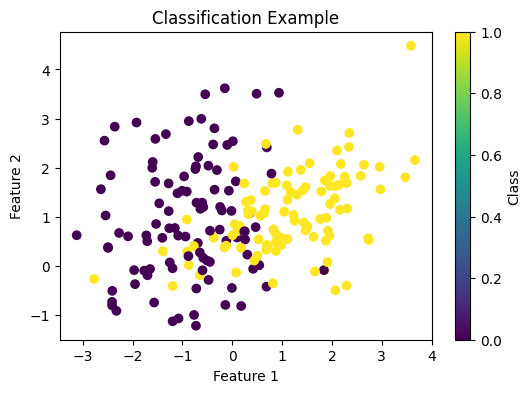

In [12]:
#그림 그리기 plot
plt.figure(figsize=(6, 4))
plt.scatter(X_cls[:, 0], X_cls[:, 1], c=y_cls, cmap='viridis')  # 첫번째feature, 두번째 feature, class에 따라 색 지정
plt.title("Classification Example")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.colorbar(label="Class")

plt.show()

### 모델 학습
1. Logistic Regression
   → 선형 구분선

2. Decision Tree
   → 계단형 구분선

3. Random Forest
   → 여러 Tree의 앙상블

4. SVM
   → margin 기반 구분

5. MLP
   → 비선형 구분선




In [51]:
# 모델 학습

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier


models = {
    "Logistic Regression": LogisticRegression(),
    "Decision Tree": DecisionTreeClassifier(max_depth=4, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=50, max_depth=4, random_state=42),
    "SVM (RBF Kernel)": SVC(kernel="rbf",  probability=True, gamma="scale"),
    "MLP": MLPClassifier(hidden_layer_sizes=(16, 16), max_iter=2000, random_state=42)
}

trained_models = {}

for name, model in models.items():
    model.fit(X_cls, y_cls)
    trained_models[name] = model
    print(f"{name} trained")


Logistic Regression trained
Decision Tree trained
Random Forest trained
SVM (RBF Kernel) trained
MLP trained


In [27]:
def plot_decision_boundary(model, X, y, title):
    #model.fit(X, y)

    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5

    xx, yy = np.meshgrid(  #300 * 300 = 90,000
        np.linspace(x_min, x_max, 300),
        np.linspace(y_min, y_max, 300)
    )

    grid = np.c_[xx.ravel(), yy.ravel()] # 각 Grid Point에 대해 모델이 예측한 Class를 계산
    Z = model.predict(grid)
    Z = Z.reshape(xx.shape)

    plt.figure(figsize=(6, 4))
    plt.contourf(xx, yy, Z, alpha=0.3)

    plt.scatter(X[y == 0, 0], X[y == 0, 1], label="Class 0")
    plt.scatter(X[y == 1, 0], X[y == 1, 1], label="Class 1")

    plt.title(title)
    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")
    plt.legend()
    plt.show()



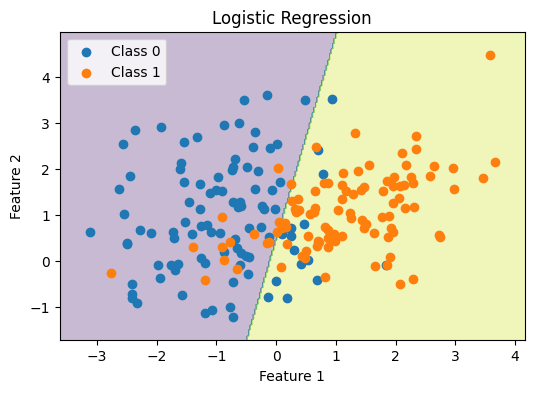

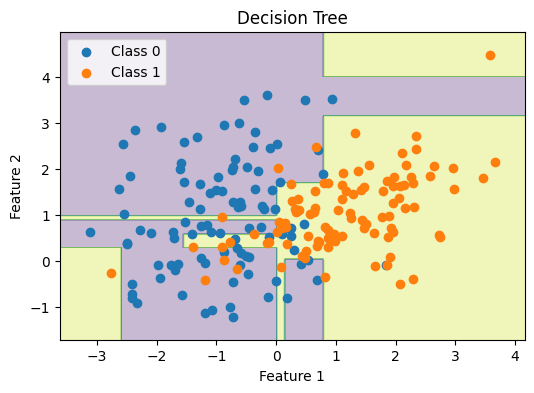

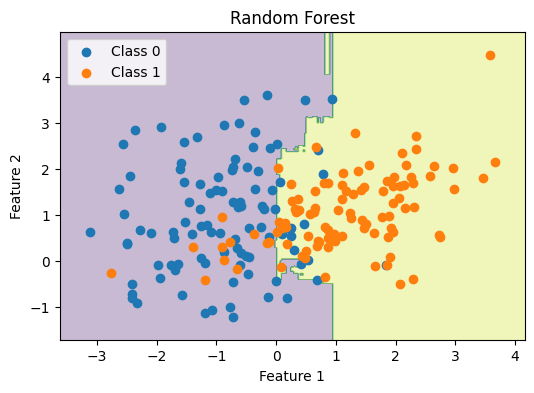

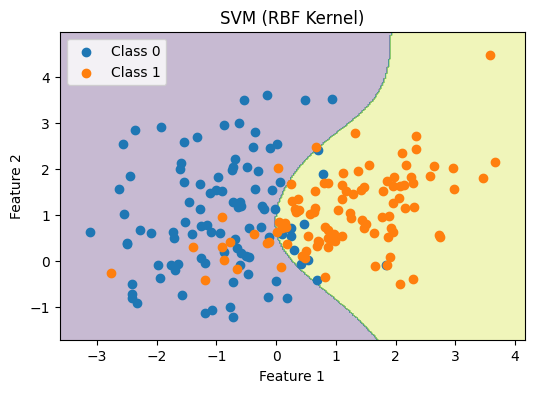

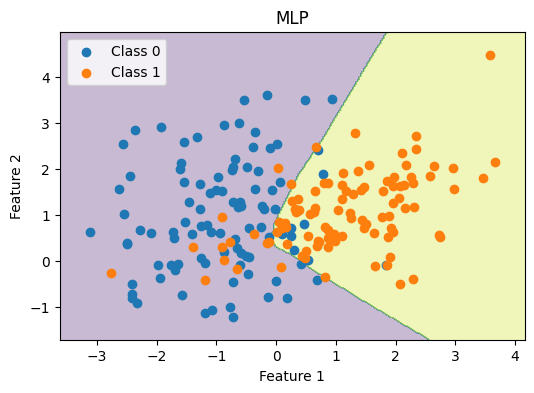

In [28]:
for name, model in trained_models.items():
    plot_decision_boundary(model, X_cls, y_cls, name)

In [38]:
# logistic regression -> 선형
"""
Feature
    ↓

z = w1*x1 + w2*x2 + b
    ↓

Sigmoid
    ↓

Probability
    ↓

if prob > 0.5
    Class 1
else
    Class 0
"""


logistic_model = trained_models["Logistic Regression"]

print("Weights")
print(logistic_model.coef_)

print("\nBias")
print(logistic_model.intercept_)

print("\nDecision Function")

w1 = logistic_model.coef_[0][0]
w2 = logistic_model.coef_[0][1]
b = logistic_model.intercept_[0]

print(
    f"z = {w1:.3f} * Feature1 + "
    f"{w2:.3f} * Feature2 + "
    f"{b:.3f}"
)

# 예제 1개
x1 = X_cls[0][0]
x2 = X_cls[0][1]

z = w1 * x1 + w2 * x2 + b

prob = 1 / (1 + np.exp(-z))

pred_class = 1 if prob > 0.5 else 0

print("\nExample")

print(f"Feature1 = {x1:.3f}")
print(f"Feature2 = {x2:.3f}")

print(f"z = {z:.3f}")
print(f"Probability = {prob:.3f}")
print(f"Predicted Class = {pred_class}")
print(f"True Class = {y_cls[0]}")

Weights
[[ 1.81773105 -0.40929647]]

Bias
[0.18734723]

Decision Function
z = 1.818 * Feature1 + -0.409 * Feature2 + 0.187

Example
Feature1 = -0.873
Feature2 = 0.013
z = -1.405
Probability = 0.197
Predicted Class = 0
True Class = 1


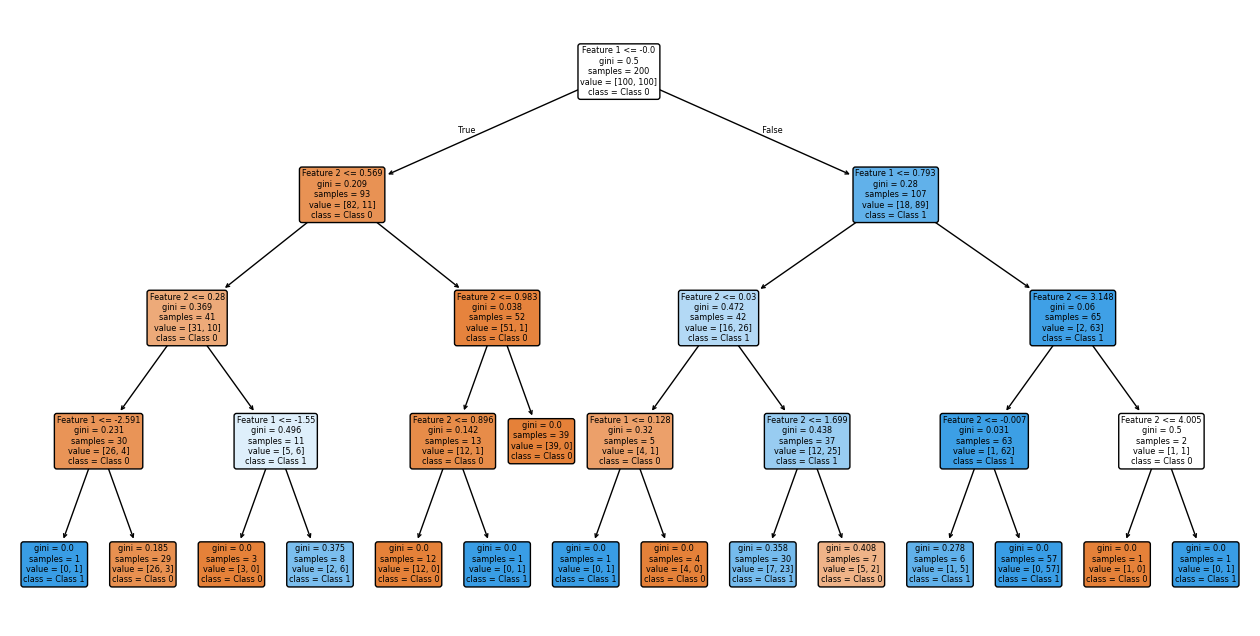

In [39]:
# decision tree -> 계단식 구분선

from sklearn.tree import plot_tree
tree_model=trained_models["Decision Tree"]

plt.figure(figsize=(16, 8))

plot_tree(
    tree_model,
    feature_names=["Feature 1", "Feature 2"],
    class_names=["Class 0", "Class 1"],
    filled=True,
    rounded=True
)

plt.show()

Number of Support Vectors
[41 40]

Support Vector Indices
[  5   7   9  11  13  15  21  23  30  32  39  41  44  47  56  60  66  84
  85  88 101 106 109 125 127 129 140 141 143 145 146 161 173 174 176 182
 186 187 193 197 199   0   1   3   6  16  25  33  34  54  58  72  74  76
  80  91  92  94  97 100 114 118 119 120 121 126 133 142 144 150 155 156
 158 164 172 178 179 181 183 190 194]


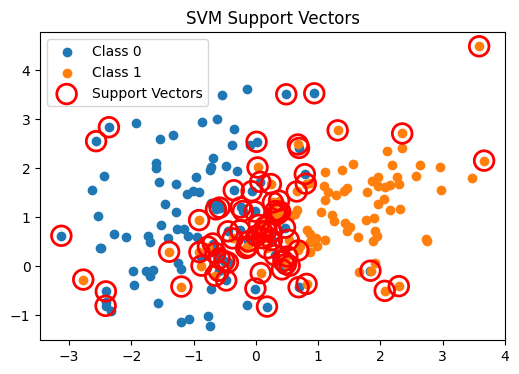

In [41]:
# SVM

"""
Support Vector

● ● ● ●
-----------
===========
-----------
○ ○ ○ ○

Support Vector
"""

svm_model = trained_models["SVM (RBF Kernel)"]

print("Number of Support Vectors")
print(svm_model.n_support_) #Class0에서 n개

print("\nSupport Vector Indices")
print(svm_model.support_) #Class0에서 m개

plt.figure(figsize=(6,4))

plt.scatter(
    X_cls[y_cls==0,0],
    X_cls[y_cls==0,1],
    label="Class 0"
)

plt.scatter(
    X_cls[y_cls==1,0],
    X_cls[y_cls==1,1],
    label="Class 1"
)

# Support Vector 강조
plt.scatter(
    svm_model.support_vectors_[:,0],
    svm_model.support_vectors_[:,1],
    s=200,
    facecolors='none',
    edgecolors='red',
    linewidths=2,
    label="Support Vectors"
)

plt.title("SVM Support Vectors")
plt.legend()
plt.show()


In [44]:
# mlp -> 비선형
"""
Input(2)
    ↓
Hidden1(16) #32
    ↓
Hidden2(16) #256
    ↓
Output(1) #16 -> 총 337 = 32+256+16+ BIAS 32개  weight / logistic은 weight 2개 bias 1개= 3개
"""

mlp_model = trained_models["MLP"]

print(mlp_model)

print("Number of Layers:", len(mlp_model.coefs_))

for i, w in enumerate(mlp_model.coefs_):
    print(f"Layer {i}")
    print("Weight Shape:", w.shape)


MLPClassifier(hidden_layer_sizes=(16, 16), max_iter=2000, random_state=42)
Number of Layers: 3
Layer 0
Weight Shape: (2, 16)
Layer 1
Weight Shape: (16, 16)
Layer 2
Weight Shape: (16, 1)


그럼 이 많은 Weight를
어떻게 학습할까?

↓

Loss Function

↓

Gradient Descent

↓

Backpropagation

### 1.4 regression

(200, 2)
(200,)


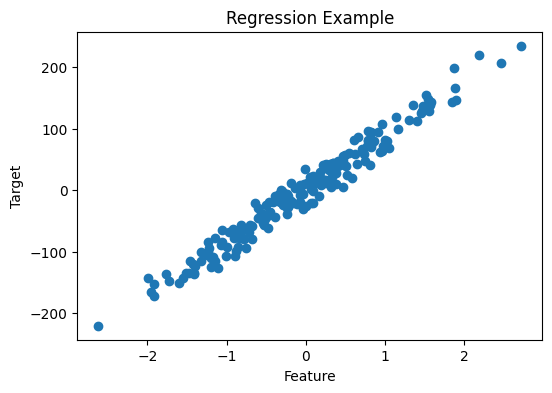

In [45]:
print(X_cls.shape)
print(y_cls.shape)# Regression dataset
X_reg, y_reg = make_regression(
    n_samples=200,
    n_features=1,
    noise=15,
    random_state=42
)

plt.figure(figsize=(6, 4))
plt.scatter(X_reg[:, 0], y_reg)
plt.title("Regression Example")
plt.xlabel("Feature")
plt.ylabel("Target")
plt.show()

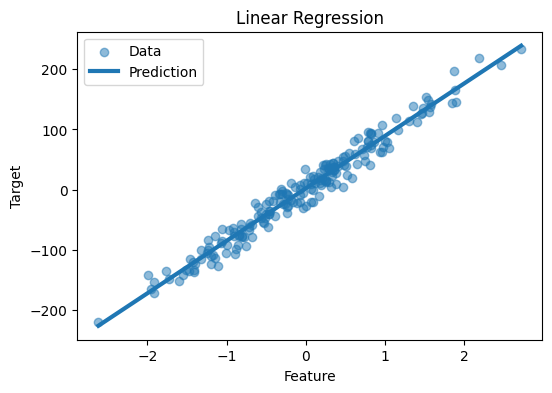

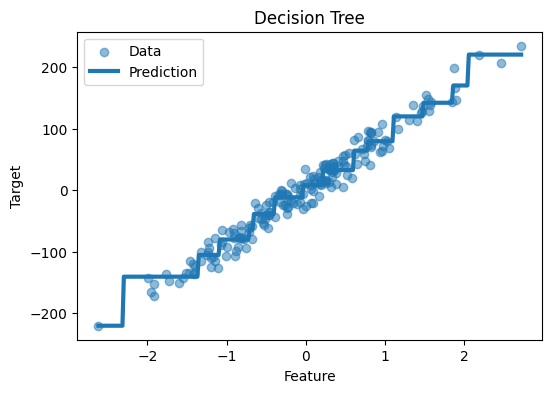

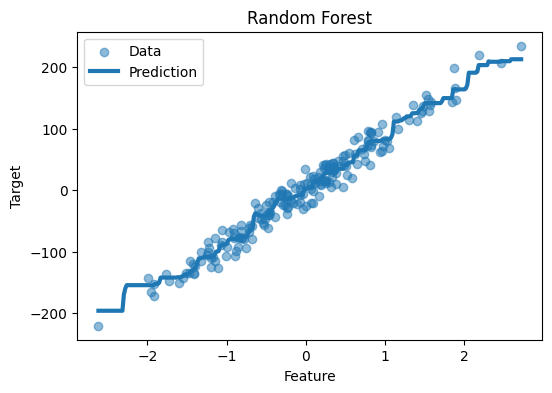

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (2000) reached and the optimization hasn't converged yet.
  warnings.warn(


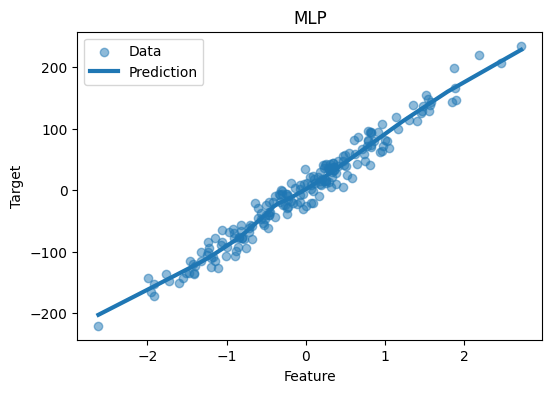

In [46]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor

reg_models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(
        max_depth=4,
        random_state=42
    ),
    "Random Forest": RandomForestRegressor(
        n_estimators=50,
        max_depth=4,
        random_state=42
    ),
    "MLP": MLPRegressor(
        hidden_layer_sizes=(16,16),
        max_iter=2000,
        random_state=42
    )
}

def plot_regression(model, X, y, title):

    model.fit(X, y)

    x_line = np.linspace(
        X.min(),
        X.max(),
        300
    ).reshape(-1,1)

    y_line = model.predict(x_line)

    plt.figure(figsize=(6,4))

    plt.scatter(
        X,
        y,
        alpha=0.5,
        label="Data"
    )

    plt.plot(
        x_line,
        y_line,
        linewidth=3,
        label="Prediction"
    )

    plt.title(title)
    plt.xlabel("Feature")
    plt.ylabel("Target")

    plt.legend()
    plt.show()

for name, model in reg_models.items():

    plot_regression(
        model,
        X_reg,
        y_reg,
        name
    )

# 2. Neural Network

Neural Network는 여러 개의 단순한 함수들을 연결하여 복잡한 함수를 표현하는 모델입니다.

가장 기본 단위는 Perceptron입니다.

---

## 2.1 Perceptron

Perceptron은 입력값에 weight를 곱하고 bias를 더한 뒤, activation function을 적용합니다.

\[
z = w_1x_1 + w_2x_2 + b
\]

\[
\hat{y} = activation(z)
\]

여기서 중요한 것은 `w`와 `b`입니다.

- Weight: 입력 feature의 중요도
- Bias: 기준점 조정


In [47]:
# Perceptron을 numpy로 직접 계산해보기

x = np.array([2.0, 3.0])      # input features
w = np.array([0.5, -0.2])     # weights
b = 0.1                       # bias

z = np.dot(x, w) + b

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

y_hat = sigmoid(z)

print("z:", z)
print("prediction:", y_hat)

z: 0.5
prediction: 0.6224593312018546


## 2.2 Activation Function

Activation Function은 Neural Network가 비선형 함수를 학습할 수 있게 해줍니다.(비선형성 추가)
대표적인 Activation Function:

- Sigmoid (발산 방지) -> Gradient Vanishing
- Tanh
- ReLU -> Gradient 흐름 개선

딥러닝에서 ReLU 계열 함수가 많이 사용됩니다.

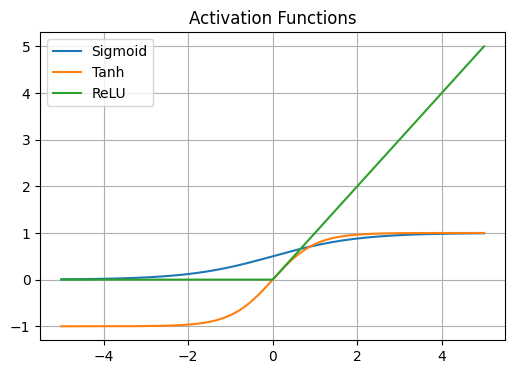

In [48]:
x = np.linspace(-5, 5, 200)

sigmoid_y = 1 / (1 + np.exp(-x))
tanh_y = np.tanh(x)
relu_y = np.maximum(0, x)

plt.figure(figsize=(6, 4))
plt.plot(x, sigmoid_y, label="Sigmoid")
plt.plot(x, tanh_y, label="Tanh")
plt.plot(x, relu_y, label="ReLU")
plt.title("Activation Functions")
plt.legend()
plt.grid(True)
plt.show()


## 2.3 Multi-Layer Perceptron

Perceptron 하나로는 단순한 decision boundary만 만들 수 있습니다.

여러 layer를 쌓으면 더 복잡한 함수를 표현할 수 있습니다.

```text
Input
  ↓
Linear
  ↓
ReLU
  ↓
Linear
  ↓
Output
```

이 구조가 Multi-Layer Perceptron, 즉 MLP입니다.


In [49]:
import torch.nn as nn

class SimpleMLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2, 8),
            nn.ReLU(),
            nn.Linear(8, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.net(x)

model = SimpleMLP().to(device)
print(model)


SimpleMLP(
  (net): Sequential(
    (0): Linear(in_features=2, out_features=8, bias=True)
    (1): ReLU()
    (2): Linear(in_features=8, out_features=1, bias=True)
    (3): Sigmoid()
  )
)


# 3. Training

Training은 모델의 weight를 조금씩 수정하면서 loss를 줄여가는 과정입니다.

핵심 흐름은 아래와 같습니다.

```text
1. Forward
2. Loss 계산
3. Backward
4. Weight update
```

PyTorch에서는 이 과정이 다음 코드 패턴으로 표현됩니다.

```python
pred = model(x)
loss = loss_fn(pred, y)
loss.backward()
optimizer.step()
optimizer.zero_grad()
```


## 3.1 Loss Function

Loss는 모델의 예측이 정답과 얼마나 다른지를 나타내는 값입니다.

중요한 점은 **Loss는 모델(Logistic Regression, MLP 등)에 의해 결정되는 것이 아니라, 해결하려는 Task(Classification, Regression 등)에 의해 결정되는 경우가 많다**는 것입니다.

예를 들어 동일한 Classification 문제라면 Logistic Regression과 MLP 모두 Binary Cross Entropy(BCE)를 사용할 수 있습니다. 반대로 동일한 MLP 모델이라도 Classification 문제를 풀 때와 Regression 문제를 풀 때는 서로 다른 Loss를 사용할 수 있습니다.

---

### Regression

Regression 문제에서는 실제값과 예측값의 차이(Residual)를 기반으로 Loss를 계산합니다.

Residual은 다음과 같이 정의됩니다.

$$
Residual = y - \hat{y}
$$

하지만 실제 학습 데이터는 수백~수만 개이므로 개별 Residual을 하나씩 보는 대신, 전체 오차를 하나의 숫자로 요약한 Loss를 사용합니다.

대표적으로 Mean Squared Error(MSE)를 사용합니다.

$$
MSE =
\frac{1}{N}
\sum_{i=1}^{N}
(y_i-\hat y_i)^2
$$

MSE는 Residual의 제곱 평균이며, 큰 오차에 더 큰 패널티를 부여합니다.

---

### Classification

Classification 문제에서는 정답 Class에 얼마나 높은 확률을 부여했는지를 평가합니다.

예를 들어 실제 정답이 Class 1일 때,

```text
모델 A : 0.95
모델 B : 0.55
```

둘 다 Class 1로 분류할 수 있지만, 모델 A가 훨씬 더 확신 있게 예측한 것입니다.

따라서 Classification에서는 단순 Residual 대신 확률 기반 Loss를 사용합니다.

대표적으로 Binary Cross Entropy(BCE)를 사용합니다.



$$
BCE =
-y\log(\hat y)
-(1-y)\log(1-\hat y)
$$

정답 Class에 높은 확률을 부여하면 Loss가 작아지고, 정답 Class에 낮은 확률을 부여하면 Loss가 커집니다.

---

### Deep Learning에서는?

Deep Learning에서는 Loss Function도 직접 설계할 수 있습니다.

예를 들어 다음과 같은 Loss들이 사용됩니다.

```text
Focal Loss
Dice Loss
Contrastive Loss
Triplet Loss
InfoNCE
```

실제 연구에서는

```text
Model Architecture
+
Loss Function
```

이 함께 성능을 결정합니다.

---

### 핵심 정리

```text
Task
↓
Loss 결정

Model
↓
Prediction 생성
```

일반적으로

```text
Regression
→ MSE

Classification
→ Cross Entropy
```

를 사용합니다.

즉, Loss는 모델보다 Task에 더 밀접하게 연결되어 있으며, Training의 목표는 결국 Loss를 최소화하는 Weight를 찾는 것입니다.

### Binary Cross Entropy (BCE)

BCE는 Binary Cross Entropy의 약자로,

```text
Binary
=
Class가 2개 (0 또는 1)

Cross Entropy
=
예측한 확률과 실제 정답 확률의 차이를 측정
```

하는 Loss Function입니다.

Classification 모델은 보통 Class를 바로 출력하지 않고 확률(Probability)을 출력합니다.

예를 들어,

```text
실제 Class = 1

모델 출력 = 0.99
```

라면

```text
99% 확률로 Class 1
```

이라고 예측한 것입니다.

여기서
```text
ŷ 는 정답 Class가 아니라,Class 1일 확률
ŷ = 0.99
99% 확률로 Class 1
```

을 의미합니다.

---

BCE는 다음과 같이 정의됩니다.

$$
BCE =
-y\log(\hat y)
-(1-y)\log(1-\hat y)
$$

여기서

```text
y      : 실제 정답 (0 또는 1)
ŷ      : 모델이 예측한 확률
```

입니다.

---

### 정답이 Class 1인 경우

만약 y = 1 이라면,
수식은

$$
BCE = -\log(\hat y)
$$

로 단순화됩니다.

예를 들어,ŷ = 0.99이면

$$
BCE = -\log(0.99)
$$

≈ 0.01

즉 Loss가 매우 작습니다.

---

반대로 ŷ = 0.01 이면,

$$
BCE = -\log(0.01)
$$

≈ 4.61

Loss가 매우 커집니다.

즉,

정답인데 확률을 높게 주면→ 작은 Loss,
정답인데 확률을 낮게 주면→ 큰 Loss


---

### 왜 Log를 사용할까?

Log를 사용하면

```text
0.99 → Loss 거의 없음

0.90 → 작은 Loss

0.50 → 중간 Loss

0.01 → 매우 큰 Loss
```

가 됩니다.

즉,

```text
틀린 예측에 매우 큰 패널티를 부여
```

할 수 있습니다.

예를 들어 실제 정답이 Class 1인데, 0.99 를 예측한 경우와 0.01을 예측한 경우를 훨씬 강하게 구분할 수 있습니다.


In [52]:
from sklearn.metrics import log_loss

print("=== Classification Loss ===")

for name, model in trained_models.items():

    # Class 1 probability
    prob = model.predict_proba(X_cls)

    loss = log_loss(y_cls, prob)

    print(f"{name:20s} BCE Loss = {loss:.4f}")

=== Classification Loss ===
Logistic Regression  BCE Loss = 0.3665
Decision Tree        BCE Loss = 0.1867
Random Forest        BCE Loss = 0.2436
SVM (RBF Kernel)     BCE Loss = 0.3246
MLP                  BCE Loss = 0.2890


위 결과는 동일한 Classification Task에 대해 여러 모델의 BCE Loss를 계산한 것입니다.

중요한 점은 모든 모델이 같은 Task를 풀고 있기 때문에 동일한 Loss Function, 즉 BCE Loss로 평가할 수 있다는 것입니다.

하지만 모델 구조가 다르기 때문에 최종 Loss 값은 달라집니다.

## 3.2 Gradient Descent (with learning rate)

앞에서 Loss는 모델이 얼마나 틀렸는지를 나타내는 값이라고 설명했습니다.

그렇다면 다음 질문이 생깁니다.

```text
Loss는 계산했다.

그럼 Loss를 어떻게 줄일 수 있을까?
```

Gradient Descent는 Loss를 줄이는 방향으로 Weight를 업데이트하는 가장 기본적인 최적화(Optimization) 방법입니다.

---

### Gradient란?

Gradient는 다음 질문에 대한 답입니다.

```text
현재 Weight를 조금 증가시키면
Loss가 얼마나 변하는가?
```

수학적으로는 Loss를 Weight로 미분한 값으로 표현합니다.

$$
\frac{\partial L}{\partial w}
$$

Gradient가 크다는 것은 해당 Weight가 Loss에 큰 영향을 주고 있다는 의미입니다.

---

### Gradient Descent

Gradient는 Loss가 가장 빠르게 증가하는 방향을 가리킵니다.

따라서 Loss를 줄이기 위해서는 Gradient의 반대 방향으로 이동해야 합니다.

Weight는 다음 식에 따라 업데이트됩니다.

$$
w_{new} = w - \eta \frac{\partial L}{\partial w}
$$
여기서,

* $w$ : 현재 Weight
* $\eta$ : Learning Rate
* $\frac{\partial L}{\partial w}$ : Gradient

입니다.

---

### Learning Rate란?

Learning Rate는 Weight를 얼마나 크게 수정할지를 결정하는 값입니다.

```text
Learning Rate가 너무 작으면
→ 학습이 매우 느려짐

Learning Rate가 너무 크면
→ 최적점을 지나쳐 학습이 불안정해짐
```

따라서 적절한 Learning Rate를 선택하는 것이 중요합니다.

---

### Example

예를 들어,

```text
현재 Weight = 5

Gradient = 2

Learning Rate = 0.1
```

이라면,

$$
w_{new} = 5 - 0.1 \times 2 = 4.8
$$

이 됩니다.

즉 Gradient가 가리키는 방향의 반대로 Weight를 조금 이동시켜 Loss를 감소시키는 것입니다.

---

### 핵심 정리

```text
Loss 계산

↓

Gradient 계산

↓

Gradient의 반대 방향으로 이동

↓

Loss 감소
```

Gradient Descent는 Loss를 줄이기 위해 Weight를 반복적으로 수정하는 방법이며, 대부분의 딥러닝 모델은 이 원리를 기반으로 학습됩니다.


=== Training Start ===
Epoch=  0 | Loss=30.000000 | Weight=0.3000
Epoch= 20 | Loss=0.045069 | Weight=1.9341
Epoch= 40 | Loss=0.000068 | Weight=1.9974
Epoch= 60 | Loss=0.000000 | Weight=1.9999
Epoch= 80 | Loss=0.000000 | Weight=2.0000

=== Training End ===
Learned Weight = 2.0000


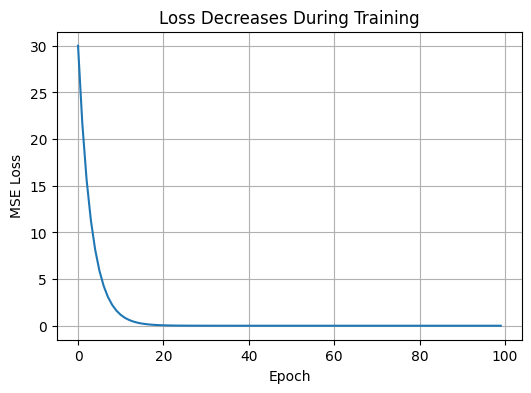

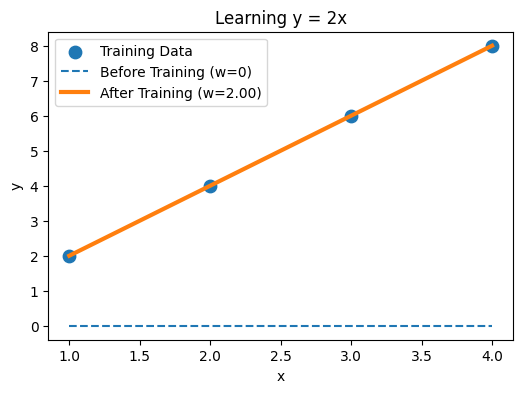

In [60]:
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# y = 2x 를 학습하는 가장 단순한 예제
# ==========================================

# Training Data
x = np.array([1, 2, 3, 4], dtype=np.float32)
y = np.array([2, 4, 6, 8], dtype=np.float32)

# 초기 Weight
w = 0.0

# Learning Rate
learning_rate = 0.01

loss_history = []

print("=== Training Start ===")

for epoch in range(100):

    # ----------------------------------
    # 1. Forward
    # y_pred = w * x
    # ----------------------------------
    y_pred = w * x

    # ----------------------------------
    # 2. Loss (MSE)
    # ----------------------------------
    loss = np.mean((y_pred - y) ** 2)

    loss_history.append(loss)

    # ----------------------------------
    # 3. Gradient
    # dLoss / dw
    # ----------------------------------
    grad = np.mean(
        2 * x * (y_pred - y)
    )

    # ----------------------------------
    # 4. Weight Update
    # ----------------------------------
    w = w - learning_rate * grad

    if epoch % 20 == 0:
        print(
            f"Epoch={epoch:3d} | "
            f"Loss={loss:.6f} | "
            f"Weight={w:.4f}"
        )

print("\n=== Training End ===")
print(f"Learned Weight = {w:.4f}")

# ==========================================
# Loss 감소 확인
# ==========================================

plt.figure(figsize=(6,4))

plt.plot(loss_history)

plt.title("Loss Decreases During Training")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")

plt.grid(True)

plt.show()

# ==========================================
# 학습 전 / 학습 후 비교
# ==========================================

plt.figure(figsize=(6,4))

plt.scatter(
    x,
    y,
    s=80,
    label="Training Data"
)

# 학습 전
plt.plot(
    x,
    np.zeros_like(x),
    "--",
    label="Before Training (w=0)"
)

# 학습 후
plt.plot(
    x,
    w * x,
    linewidth=3,
    label=f"After Training (w={w:.2f})"
)

plt.title("Learning y = 2x")
plt.xlabel("x")
plt.ylabel("y")

plt.legend()

plt.show()

## 3.3 Backpropagation

Backpropagation은 loss에서 시작해서 각 weight가 loss에 얼마나 영향을 주었는지 계산하는 알고리즘입니다.

PyTorch에서는 `loss.backward()`가 이 역할을 수행합니다.

중요한 점은 다음입니다.

> Backpropagation은 모든 weight에 대한 gradient를 계산하고, optimizer가 그 gradient를 이용해 weight를 업데이트한다.


즉,

```text
loss.backward()
```

는 Gradient를 계산하고,

```text
optimizer.step()
```

은 계산된 Gradient를 이용하여 Weight를 수정합니다.

실제로 Gradient와 Weight가 어떻게 변하는지 확인해보겠습니다.

In [65]:
# PyTorch로 Classification 학습 + Backpropagation 중간 과정 보기

import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# ==========================================
# 1. Dataset 생성
# ==========================================

X, y = make_classification(
    n_samples=1000,
    n_features=2,
    n_redundant=0,
    n_informative=2,
    random_state=42,
    n_clusters_per_class=1
)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

device = "cuda" if torch.cuda.is_available() else "cpu"

X_train_t = torch.tensor(X_train, dtype=torch.float32).to(device)
y_train_t = torch.tensor(y_train.reshape(-1, 1), dtype=torch.float32).to(device)

X_test_t = torch.tensor(X_test, dtype=torch.float32).to(device)
y_test_t = torch.tensor(y_test.reshape(-1, 1), dtype=torch.float32).to(device)



In [66]:
# ==========================================
# 2. MLP Model 정의
# ==========================================

class SimpleMLP(nn.Module):
    def __init__(self):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(2, 16),
            nn.ReLU(),
            nn.Linear(16, 16),
            nn.ReLU(),
            nn.Linear(16, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.net(x)

model = SimpleMLP().to(device)

print("=== Model Structure ===")
print(model)

print("\n=== Model Parameters ===")
for name, param in model.named_parameters():
    print(name, param.shape)

# ==========================================
# 3. Loss Function / Optimizer
# ==========================================

loss_fn = nn.BCELoss()

optimizer = torch.optim.SGD(
    model.parameters(),
    lr=0.01
)



=== Model Structure ===
SimpleMLP(
  (net): Sequential(
    (0): Linear(in_features=2, out_features=16, bias=True)
    (1): ReLU()
    (2): Linear(in_features=16, out_features=16, bias=True)
    (3): ReLU()
    (4): Linear(in_features=16, out_features=1, bias=True)
    (5): Sigmoid()
  )
)

=== Model Parameters ===
net.0.weight torch.Size([16, 2])
net.0.bias torch.Size([16])
net.2.weight torch.Size([16, 16])
net.2.bias torch.Size([16])
net.4.weight torch.Size([1, 16])
net.4.bias torch.Size([1])


In [82]:
# ==========================================
# 4. Backpropagation 한 번 자세히 보기
# ==========================================

torch.set_printoptions(
    precision=10,
    sci_mode=False
)

model.train()

pred = model(X_train_t)
loss = loss_fn(pred, y_train_t)

print("\n=== Before Backpropagation ===")
print("이 Loss를 줄이기 위해 각 Weight의 Gradient를 계산합니다.")
print("Loss:", loss.item())

# 첫 번째 Weight 가져오기
first_param_name, first_param = next(model.named_parameters())

print("\n=== Target Weight Matrix ===")
print("Parameter Name:", first_param_name)

# Update 전 Weight 저장
before = first_param.data.clone()

print("\n[1] Weight Before Update")
print("업데이트 전 Weight 값입니다.")
print(before[:3])

# Gradient 초기화
optimizer.zero_grad()

print("\n[2] optimizer.zero_grad()")
print("이전 step에서 계산된 Gradient가 남아있을 수 있으므로 먼저 초기화합니다.")

# Backpropagation: 각 weight의 gradient 계산
loss.backward()

print("\n[3] loss.backward()")
print("Backpropagation을 수행하여 각 Weight에 대한 Gradient를 계산합니다.")

# Gradient 저장
grad = first_param.grad.clone()

print("\n[4] Gradient of Weight")
print("아래 값은 dLoss/dWeight 입니다.")
print("각 숫자는 해당 Weight를 조금 바꿨을 때 Loss가 얼마나 변하는지를 의미합니다.")
print(grad[:3])

# Weight Update: gradient를 이용해서 weight 수정
optimizer.step()

print("\n[5] optimizer.step()")
print("Optimizer가 Gradient를 이용해 Weight를 업데이트합니다.")
print("SGD 기준 업데이트 식은 다음과 같습니다.")
print("W_new = W_old - learning_rate * gradient")

# Update 후 Weight 저장
after = first_param.data.clone()

print("\n[6] Weight After Update")
print("업데이트 후 Weight 값입니다.")
print(after[:3])

print("\n[7] Actual Change")
print("실제로 Weight가 얼마나 바뀌었는지 계산합니다.")
print("Actual Change = W_after - W_before")
print(after[:3] - before[:3])



=== Before Backpropagation ===
이 Loss를 줄이기 위해 각 Weight의 Gradient를 계산합니다.
Loss: 0.1485593020915985

=== Target Weight Matrix ===
Parameter Name: net.0.weight

[1] Weight Before Update
업데이트 전 Weight 값입니다.
tensor([[ 0.6952260733,  0.1971018910],
        [-0.5721930861, -0.5425813794],
        [-0.8128313422, -0.7491109371]], device='cuda:0')

[2] optimizer.zero_grad()
이전 step에서 계산된 Gradient가 남아있을 수 있으므로 먼저 초기화합니다.

[3] loss.backward()
Backpropagation을 수행하여 각 Weight에 대한 Gradient를 계산합니다.

[4] Gradient of Weight
아래 값은 dLoss/dWeight 입니다.
각 숫자는 해당 Weight를 조금 바꿨을 때 Loss가 얼마나 변하는지를 의미합니다.
tensor([[ 0.0040179058, -0.0014960391],
        [-0.0007469855, -0.0010119490],
        [-0.0004182663,  0.0014978746]], device='cuda:0')

[5] optimizer.step()
Optimizer가 Gradient를 이용해 Weight를 업데이트합니다.
SGD 기준 업데이트 식은 다음과 같습니다.
W_new = W_old - learning_rate * gradient

[6] Weight After Update
업데이트 후 Weight 값입니다.
tensor([[ 0.6920337677,  0.1979003102],
        [-0.5695726275, -0.5455603600],
        [-0.81306451

Epoch=  0 | Loss=0.1223
Epoch= 50 | Loss=0.1222
Epoch=100 | Loss=0.1222
Epoch=150 | Loss=0.1221


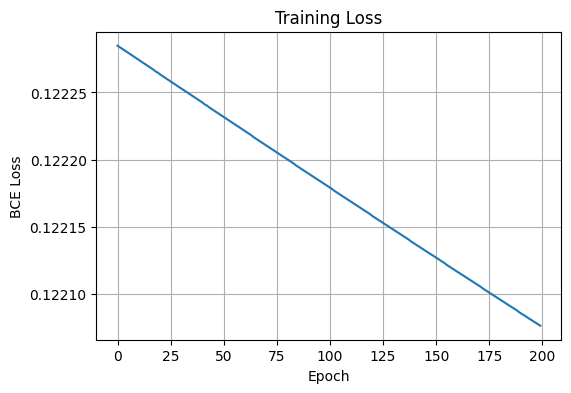

Test Accuracy: 0.9350000023841858


In [73]:
# ==========================================
# 5. Training Loop
# ==========================================

loss_history = []

for epoch in range(200):

    model.train()

    # 1. Forward
    pred = model(X_train_t)

    # 2. Loss 계산
    loss = loss_fn(pred, y_train_t)

    # 3. Gradient 초기화
    optimizer.zero_grad()

    # 4. Backpropagation
    loss.backward()

    # 5. Weight Update
    optimizer.step()

    loss_history.append(loss.item())

    if epoch % 50 == 0:
        print(
            f"Epoch={epoch:3d} | "
            f"Loss={loss.item():.4f}"
        )

# ==========================================
# 6. Loss Curve
# ==========================================

plt.figure(figsize=(6, 4))

plt.plot(loss_history)

plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("BCE Loss")
plt.grid(True)

plt.show()

# ==========================================
# 7. Test Accuracy
# ==========================================

model.eval()

with torch.no_grad():

    test_pred = model(X_test_t)

    test_pred_label = (test_pred > 0.5).float()

    accuracy = (
        test_pred_label == y_test_t
    ).float().mean()

print("Test Accuracy:", accuracy.item())

# 4. Overfitting

Overfitting은 모델이 training data에는 너무 잘 맞지만, 새로운 데이터에는 잘 동작하지 않는 현상입니다.

즉, 모델이 일반적인 패턴을 배운 것이 아니라 training data를 외워버린 상태입니다.

---

## Overfitting을 줄이는 방법

1. 더 많은 데이터
2. Regularization
3. Dropout
4. Early Stopping
5. 모델 크기 줄이기


## 4.1 Train Loss와 Validation Loss

Overfitting은 보통 아래 패턴으로 나타납니다.

```text
Train loss: 계속 감소
Validation loss: 어느 순간부터 증가
```

이때 validation loss가 증가하기 시작하는 지점에서 학습을 멈추는 것이 Early Stopping입니다.

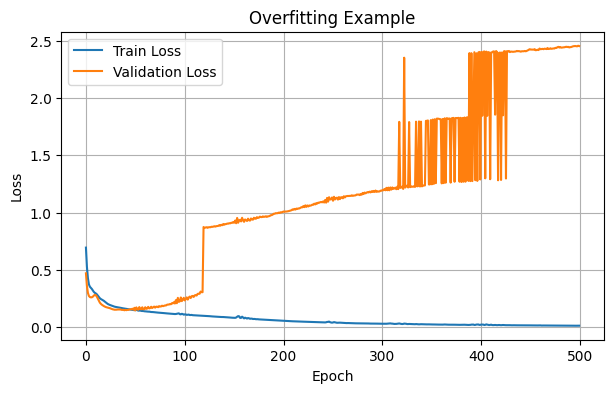

In [76]:
# 작은 데이터 + 큰 모델로 overfitting을 관찰해보기

from sklearn.datasets import make_moons

X, y = make_moons(n_samples=300, noise=0.25, random_state=42)

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.5, random_state=42
)

X_train_t = torch.tensor(X_train, dtype=torch.float32).to(device)
y_train_t = torch.tensor(y_train.reshape(-1, 1), dtype=torch.float32).to(device)

X_val_t = torch.tensor(X_val, dtype=torch.float32).to(device)
y_val_t = torch.tensor(y_val.reshape(-1, 1), dtype=torch.float32).to(device)

class LargeMLP(nn.Module):
    def __init__(self, use_dropout=False):
        super().__init__()

        layers = [
            nn.Linear(2, 128),
            nn.ReLU(),
        ]

        if use_dropout:
            layers.append(nn.Dropout(0.3))

        layers += [
            nn.Linear(128, 128),
            nn.ReLU(),
        ]

        if use_dropout:
            layers.append(nn.Dropout(0.3))

        layers += [
            nn.Linear(128, 1),
            nn.Sigmoid()
        ]

        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

model = LargeMLP(use_dropout=False).to(device)
loss_fn = nn.BCELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

train_losses = []
val_losses = []

for epoch in range(500):
    model.train()
    pred = model(X_train_t)
    train_loss = loss_fn(pred, y_train_t)

    optimizer.zero_grad()
    train_loss.backward()
    optimizer.step()

    model.eval()
    with torch.no_grad():
        val_pred = model(X_val_t)
        val_loss = loss_fn(val_pred, y_val_t)

    train_losses.append(train_loss.item())
    val_losses.append(val_loss.item())

plt.figure(figsize=(7, 4))
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")
plt.title("Overfitting Example")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()


## 4.2 Dropout

Dropout은 학습 중 일부 neuron을 랜덤하게 꺼서 모델이 특정 feature나 neuron에 과도하게 의존하지 않도록 만드는 방법입니다.

```python
nn.Dropout(0.3)
```

위 코드는 학습 중 30%의 neuron을 랜덤하게 비활성화합니다.


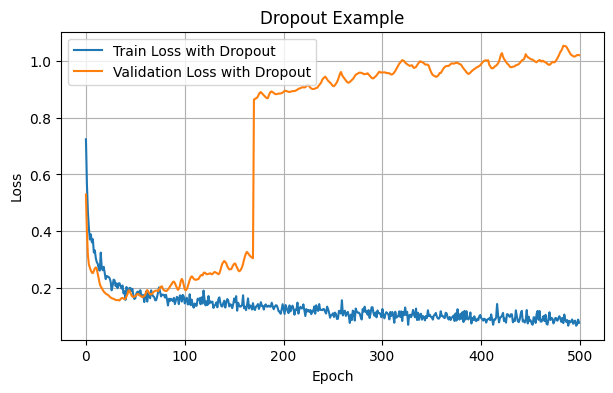

In [77]:
# Dropout을 사용한 모델과 비교

model = LargeMLP(use_dropout=True).to(device)
loss_fn = nn.BCELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

train_losses_dropout = []
val_losses_dropout = []

for epoch in range(500):
    model.train()
    pred = model(X_train_t)
    train_loss = loss_fn(pred, y_train_t)

    optimizer.zero_grad()
    train_loss.backward()
    optimizer.step()

    model.eval()
    with torch.no_grad():
        val_pred = model(X_val_t)
        val_loss = loss_fn(val_pred, y_val_t)

    train_losses_dropout.append(train_loss.item())
    val_losses_dropout.append(val_loss.item())

plt.figure(figsize=(7, 4))
plt.plot(train_losses_dropout, label="Train Loss with Dropout")
plt.plot(val_losses_dropout, label="Validation Loss with Dropout")
plt.title("Dropout Example")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()


## 4.3 Early Stopping

Early Stopping은 validation loss가 더 이상 좋아지지 않으면 학습을 멈추는 방법입니다.

실제 연구/개발에서는 거의 항상 validation set을 따로 두고, validation 성능을 기준으로 best checkpoint를 저장합니다.

In [78]:
# Early Stopping 예시 코드

model = LargeMLP(use_dropout=True).to(device)
loss_fn = nn.BCELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

best_val_loss = float("inf")
patience = 30
patience_counter = 0

best_epoch = 0

for epoch in range(500):
    model.train()
    pred = model(X_train_t)
    train_loss = loss_fn(pred, y_train_t)

    optimizer.zero_grad()
    train_loss.backward()
    optimizer.step()

    model.eval()
    with torch.no_grad():
        val_pred = model(X_val_t)
        val_loss = loss_fn(val_pred, y_val_t).item()

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_epoch = epoch
        patience_counter = 0
    else:
        patience_counter += 1

    if patience_counter >= patience:
        print(f"Early stopping at epoch {epoch}")
        break

print("Best epoch:", best_epoch)
print("Best validation loss:", best_val_loss)


Early stopping at epoch 82
Best epoch: 52
Best validation loss: 0.14651744067668915


# 5. Session 1 정리

이번 세션에서는 LLM을 이해하기 위한 가장 기본적인 학습 원리를 배웠습니다.

## 핵심 요약

### Machine Learning

데이터로부터 패턴을 학습하는 방법입니다.

### Neural Network

여러 개의 weight와 activation function을 조합하여 복잡한 함수를 표현합니다.

### Loss

모델 예측이 정답과 얼마나 다른지 측정합니다.

### Gradient Descent

Loss를 줄이는 방향으로 weight를 업데이트합니다.

### Backpropagation

각 weight가 loss에 얼마나 영향을 미쳤는지 gradient를 계산합니다.

### Overfitting

모델이 training data를 외워서 새로운 데이터에 약해지는 현상입니다.

---



# 다음 세션 예고

## Session 2. Transformer

다음 세션에서는 GPT 논문을 읽기 위한 핵심 개념을 배웁니다.

- Why RNN Failed
- Attention
- Query / Key / Value
- Multi-Head Attention
- Positional Encoding
- RoPE
- Transformer Block
- KV Cache
- Prefill / Decode

대표 논문:

- Attention Is All You Need
- RoFormer
